# Point clouds: `.pcd` and `.xyz`

meshio++ reads and writes the two point-cloud file families a scanner or
[PCL](https://pointclouds.org/) pipeline hands you: **`.pcd`** (the Point Cloud
Library's v0.7 layout, in all three `DATA` modes) and headerless **`.xyz`**
(with the `.xyzn`, `.xyzrgb`, `.asc`, `.pts` and `.txt` aliases). Both map to the
points plus one `vertex` block, which is exactly what `subsample_points` emits,
so a cloud goes from a file to a budgeted subsample to a proximity graph with no
intermediate format:

```sh
meshioplusplus subsample cloud.pcd small.pcd -n 20000
meshioplusplus proximity-graph small.pcd graph.vtu --knn 8
```

This notebook runs on four files from PCL's own test corpus
(`tests/python/meshes/pcd/`, BSD-3): an ASCII cloud with normals, a binary
organised cloud, and two `binary_compressed` clouds.

In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from matplotlib.collections import LineCollection

import meshioplusplus as mp

# Head-less, static rendering (no display / live server needed).
pv.OFF_SCREEN = True
pv.set_jupyter_backend('static')

PCD = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'tests', 'python', 'meshes', 'pcd')


def show(img, title=None, figsize=(9, 6)):
    """Embed a rendered RGB screenshot as a static image."""
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


def render_cloud(mesh, title, colors=None, point_size=3.0):
    """Render a point cloud with PyVista, or with matplotlib when GL is unavailable."""
    try:
        pl = pv.Plotter(off_screen=True, window_size=(1000, 720))
        cloud = pv.PolyData(np.asarray(mesh.points, dtype=float))
        if colors is not None:
            cloud['rgb'] = colors
            pl.add_mesh(cloud, scalars='rgb', rgb=True, point_size=point_size,
                        render_points_as_spheres=True)
        else:
            pl.add_mesh(cloud, color='#2ec4b6', point_size=point_size,
                        render_points_as_spheres=True)
        pl.camera_position = 'iso'
        pl.add_axes()
        img = pl.screenshot(return_img=True)
        pl.close()
        show(img, title)
    except Exception as exc:  # pragma: no cover - head-less GL fallback
        print('PyVista render skipped:', exc)
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(projection='3d')
        p = np.asarray(mesh.points)
        ax.scatter(p[:, 0], p[:, 1], p[:, 2], s=1, c=None if colors is None else colors / 255)
        ax.set_title(title)
        plt.show()


print('pyvista :', mp.has_pyvista())

pyvista : True


## Read a PCL file

`pcl_logo.pcd` is `DATA binary_compressed`: an LZF stream over the
struct-of-arrays layout. PCL stores its `rgb` field as a `uint32`
(`0x00RRGGBB`) **inside a `float32` slot**, so the colours have to be unpacked
by bit-cast, never by value — meshio++ hands them back as an `(n, 3)` `uint8`
array named `rgb`. The header's `VIEWPOINT` is recorded in `field_data` and is
never applied to the points.

<meshio++ mesh object>
  Number of points: 12909
  Number of cells:
    vertex: 12909
  Point data: rgb
  Field data: pcd:viewpoint
points   : (12909, 3) float32
cells    : [('vertex', (12909, 1))]
rgb      : (12909, 3) uint8
viewpoint: [ 0.  0. -2.  0.  1.  0.  0.]


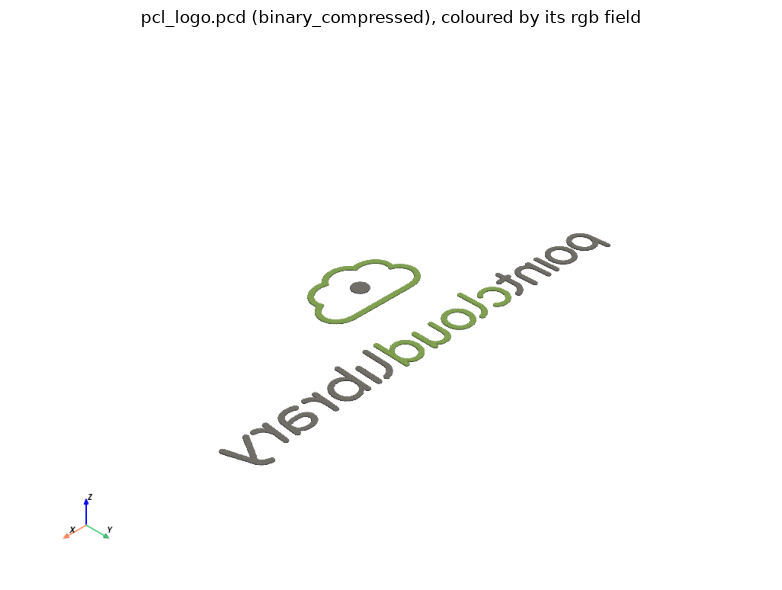

In [2]:
logo = mp.read(os.path.join(PCD, 'pcl_logo.pcd'))
print(logo)
print('points   :', logo.points.shape, logo.points.dtype)
print('cells    :', [(c.type, c.data.shape) for c in logo.cells])
print('rgb      :', logo.point_data['rgb'].shape, logo.point_data['rgb'].dtype)
print('viewpoint:', logo.field_data['pcd:viewpoint'])
render_cloud(logo, 'pcl_logo.pcd (binary_compressed), coloured by its rgb field',
             colors=logo.point_data['rgb'])

## What each file carries

Point data is keyed by field name: `normal_x/y/z` gather into `normals`,
`rgb`/`rgba` unpack to `uint8`, any other field keeps its name and dtype, and
`COUNT > 1` gives an `(n, count)` array. `colored_cloud.pcd` is an *organised*
cloud (`HEIGHT > 1`), so its `WIDTH`/`HEIGHT` ride along in `field_data` and are
restored on write.

In [3]:
rows = []
for name in ['bun0', 'colored_cloud', 'pcl_logo', 'milk_color']:
    path = os.path.join(PCD, name + '.pcd')
    with open(path, 'rb') as f:
        head = f.read(700).decode('latin-1')
    data_mode = [l.split()[1] for l in head.splitlines() if l.startswith('DATA')][0]
    m = mp.read(path)
    rows.append((name, data_mode, len(m.points), str(m.points.dtype),
                 ', '.join(f"{k}{tuple(v.shape[1:]) or ''}" for k, v in m.point_data.items()),
                 ', '.join(m.field_data) or '-'))
print(f"{'file':14s} {'DATA':18s} {'points':>7s} {'dtype':8s} point data / field data")
for name, mode, n, dt, pd_, fd in rows:
    print(f'{name:14s} {mode:18s} {n:7d} {dt:8s} {pd_}  |  {fd}')

file           DATA                points dtype    point data / field data
bun0           ascii                  397 float32  curvature, normals(3,)  |  -
colored_cloud  binary                1000 float32  curvature, normals(3,), rgb(3,)  |  pcd:height, pcd:width
pcl_logo       binary_compressed    12909 float32  rgb(3,)  |  pcd:viewpoint
milk_color     binary_compressed    13704 float32  rgba(4,)  |  -


## The three `DATA` modes

`data="ascii" | "binary" | "binary_compressed"` (binary is the default). The
writer defaults to **float32** coordinates, the only precision PCL's typed
`PointXYZ` loaders accept; `point_dtype="float64"` keeps double precision and
`"keep"` follows the mesh. Every mode reads back to exactly the same cloud.

{'ascii': '522 KiB', 'binary': '202 KiB', 'binary_compressed': '25 KiB'} - every mode round-trips exactly


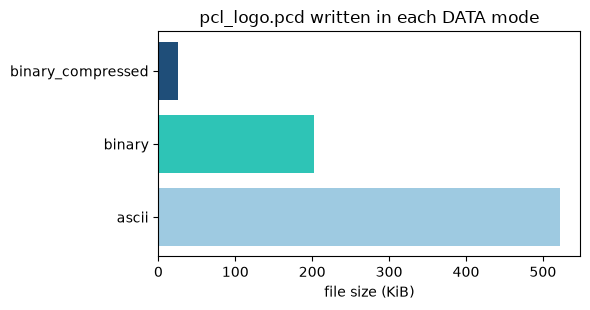

In [4]:
tmp = tempfile.mkdtemp()
sizes = {}
for mode in ('ascii', 'binary', 'binary_compressed'):
    out = os.path.join(tmp, f'logo_{mode}.pcd')
    mp.pcd.write(out, logo, data=mode)
    back = mp.pcd.read(out)
    assert np.array_equal(back.points, logo.points)
    assert np.array_equal(back.point_data['rgb'], logo.point_data['rgb'])
    sizes[mode] = os.path.getsize(out)
print({k: f'{v / 1024:.0f} KiB' for k, v in sizes.items()}, '- every mode round-trips exactly')

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.barh(list(sizes), [v / 1024 for v in sizes.values()], color=['#9ecae1', '#2ec4b6', '#1f4e79'])
ax.set_xlabel('file size (KiB)')
ax.set_title('pcl_logo.pcd written in each DATA mode')
plt.tight_layout()
plt.show()

## From a file to a graph

`subsample_points` picks a budget of well-spread points (farthest-point
sampling here) and carries the colours with them; `proximity_graph` links the
survivors by `knn` or by interaction `radius`. Reading a `.pcd` gives the same
`vertex`-block shape the operation emits, so nothing is reported as dropped.

subsampled: 12909 -> 1500 points; kept ['rgb']
knn graph  : 801 directed edges on 350 points


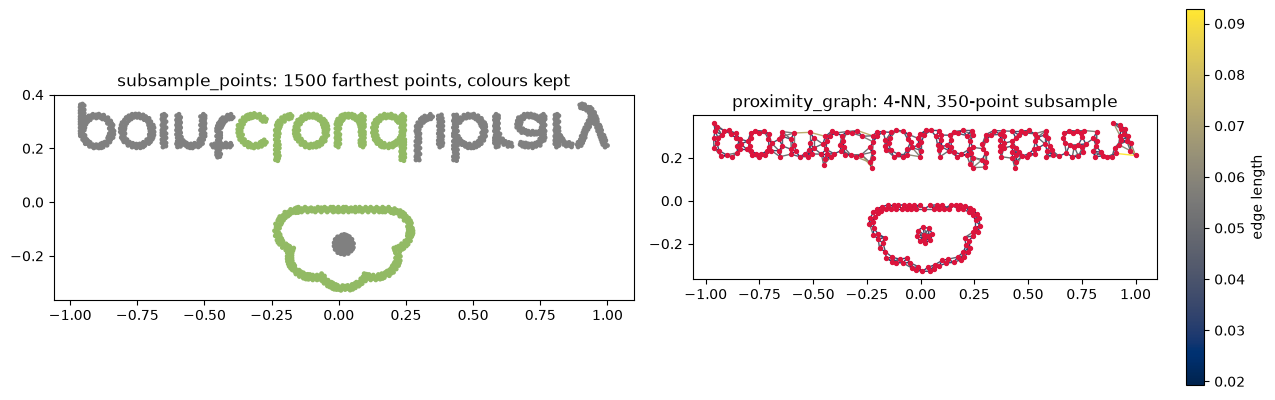

In [5]:
from matplotlib.collections import LineCollection

cloud = mp.subsample_points(logo, 1500)
print('subsampled:', len(logo.points), '->', len(cloud.points), 'points; kept', sorted(cloud.point_data))

# A sparser subsample for the graph, so the edges are visible.
sparse = mp.subsample_points(logo, 350)
edges = mp.proximity_graph(sparse, method='knn', max_neighbors=4, undirected=False)
print('knn graph  :', edges.shape[1], 'directed edges on', len(sparse.points), 'points')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
p = cloud.points
axes[0].scatter(p[:, 0], p[:, 1], s=6, c=cloud.point_data['rgb'] / 255.0)
axes[0].set_title('subsample_points: 1500 farthest points, colours kept')
q = sparse.points
segs = q[edges.T][:, :, :2]
lengths = np.linalg.norm(np.diff(q[edges.T], axis=1)[:, 0], axis=1)
coll = LineCollection(segs, cmap='cividis', linewidths=1.0)
coll.set_array(lengths)
axes[1].add_collection(coll)
axes[1].scatter(q[:, 0], q[:, 1], s=8, c='crimson', zorder=3)
axes[1].autoscale()
axes[1].set_title('proximity_graph: 4-NN, 350-point subsample')
fig.colorbar(coll, ax=axes[1], shrink=0.8, label='edge length')
for ax in axes:
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# and the same chain written out: the graph is line cells, so it goes to a mesh format
mp.write(os.path.join(tmp, 'graph.vtu'), mp.Mesh(q, [('line', np.ascontiguousarray(edges.T))]))

## Organised clouds

A range-image cloud (`HEIGHT > 1`) marks invalid returns with NaN. meshio++ keeps
the cloud whole by default — NaN rows included, `WIDTH`/`HEIGHT` recorded — and
`drop_invalid=True` removes the non-finite points (and with them the
organisation). Here `colored_cloud.pcd` has no invalid returns, so a NaN row is
injected to show both.

In [6]:
org = mp.read(os.path.join(PCD, 'colored_cloud.pcd'))
print('organised:', org.field_data['pcd:width'], 'x', org.field_data['pcd:height'], '=', len(org.points), 'points')

org.points[3] = np.nan
path = os.path.join(tmp, 'holes.pcd')
mp.pcd.write(path, org, data='ascii')
kept = mp.pcd.read(path)
dropped = mp.pcd.read(path, drop_invalid=True)
print('kept    :', len(kept.points), 'points,', int(np.isnan(kept.points).any(axis=1).sum()), 'NaN row, organisation', list(kept.field_data))
print('dropped :', len(dropped.points), 'points, field data', list(dropped.field_data))

organised: [1] x [1000] = 1000 points
kept    : 1000 points, 1 NaN row, organisation ['pcd:height', 'pcd:width']
dropped : 999 points, field data []


## `.xyz`: a convention, not a specification

There is no header to tell you what the columns mean, so meshio++ resolves them
in order: an explicit `columns=` list, a header comment naming them (what the
writer emits, so files round-trip), the column count and file extension, then the
value ranges. Six columns are ambiguous — unit vectors are taken as normals,
byte-valued integers as colours — and anything still unclear is an error asking
for `columns=`, not a guess. Chemistry XYZ (atom count, comment, `element x y z`)
shares the extension and is refused by name.

In [7]:
out = os.path.join(tmp, 'logo.xyz')
mp.xyz.write(out, cloud)
with open(out) as f:
    print(''.join(list(f)[:4]))
back = mp.read(out)
print('read back:', back.points.shape, {k: v.dtype.name for k, v in back.point_data.items()})

def attempt(name, text, **kw):
    path = os.path.join(tmp, name)
    with open(path, 'w') as f:
        f.write(text)
    try:
        m = mp.xyz.read(path, **kw)
        print(f'{name:11s} ->', {k: v.shape for k, v in m.point_data.items()} or 'points only')
    except mp.ReadError as exc:
        print(f'{name:11s} -> refused:', str(exc).split(': ', 1)[-1][:110])

attempt('a.xyz', '1 2 3\n4 5 6\n')
attempt('b.xyz', '1 2 3 0 0 1\n4 5 6 0 1 0\n')                       # unit vectors: normals
attempt('c.xyz', '1 2 3 10 20 30\n4 5 6 40 50 60\n')                   # bytes: colours
attempt('d.xyz', '1 2 3 5.5 6.5 7.5\n4 5 6 4.5 5.5 6.5\n')             # ambiguous
attempt('e.xyz', '1 2 3 5.5 6.5 7.5\n4 5 6 4.5 5.5 6.5\n', columns=['x', 'y', 'z', 'pressure', 'temperature', 'density'])
attempt('f.pts', '2\n1 2 3 100 255 0 0\n4 5 6 200 0 255 0\n')         # .pts: count + xyz + intensity + rgb
attempt('water.xyz', '3\nwater\nO 0 0 0\nH 0.7 0 0.7\nH -0.7 0 0.7\n')  # chemistry XYZ

# Written by meshio++ v15.1.0
# x y z r g b
-0.961899996 0.246600002 0 128 128 128
1 0.210700005 0 128 128 128

read back: (1500, 3) {'rgb': 'uint8'}
a.xyz       -> points only
b.xyz       -> {'normals': (2, 3)}
c.xyz       -> {'rgb': (2, 3)}
d.xyz       -> refused: cannot tell what the 6 columns are; pass columns=[...] (names x y z nx ny nz r g b a, any other name is a scal
e.xyz       -> {'density': (2,), 'pressure': (2,), 'temperature': (2,)}
f.pts       -> {'intensity': (2,), 'rgb': (2, 3)}
water.xyz   -> refused: this looks like a chemistry/molecular XYZ file (atom count, a comment line, then 'element x y z' rows), not a 
